# 🌦️ Weather Summary Classification

## 📌 Problem Statement

The goal is to classify weather conditions using meteorological features such as temperature, humidity, visibility, and wind attributes.

The project focuses on building a robust ML pipeline with proper preprocessing, class handling, and evaluation using macro F1 score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("weatherHistory.csv")
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251,15.8263,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259,15.8263,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204,14.9569,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269,15.8263,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259,15.8263,1016.51,Partly cloudy throughout the day.


## Data Cleaning

- Removed duplicates  
- Handled missing values  
- Ensured consistency  

In [3]:
df.drop_duplicates(inplace=True)
df.ffill(inplace=True)

## Drop Irrelevant Columns

Columns like Formatted Date and Daily Summary were removed as they do not contribute to prediction.

In [4]:
df = df.drop(['Formatted Date', 'Daily Summary'], axis=1)

## Exploratory Data Analysis (EDA)

Basic analysis was performed to understand feature distributions and relationships.

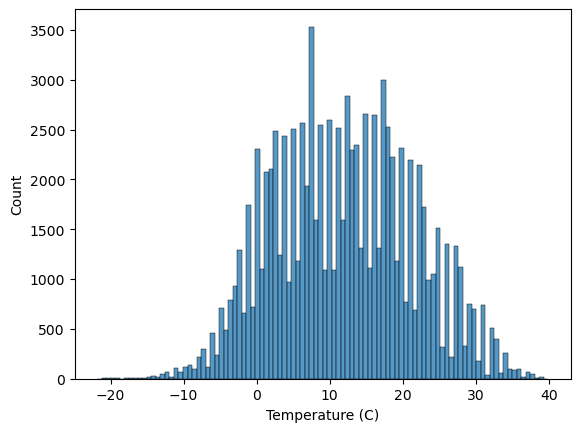

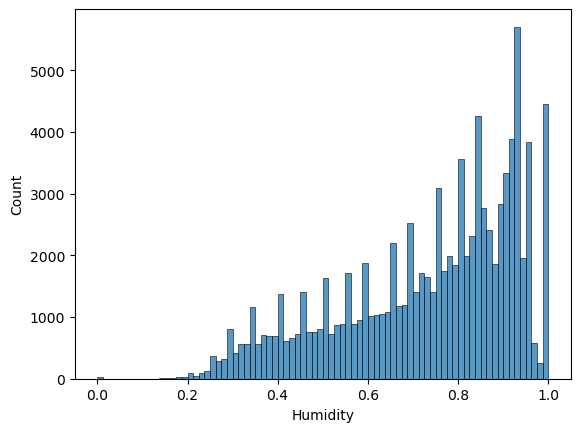

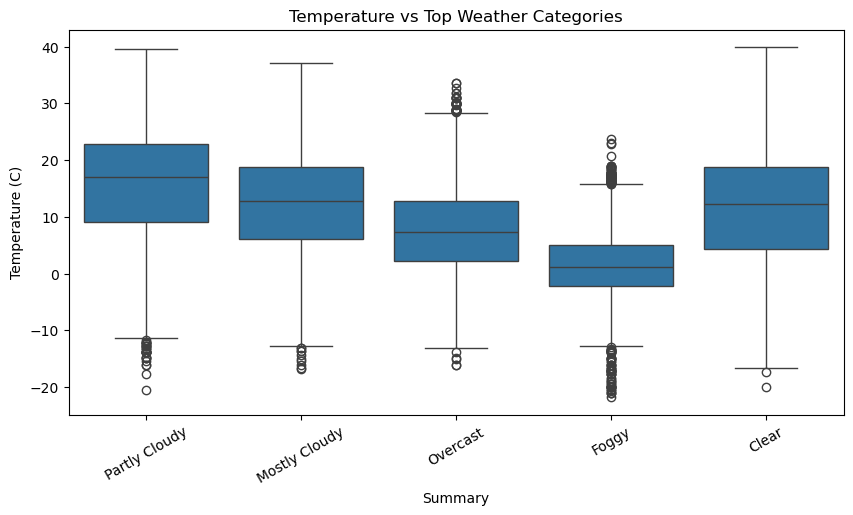

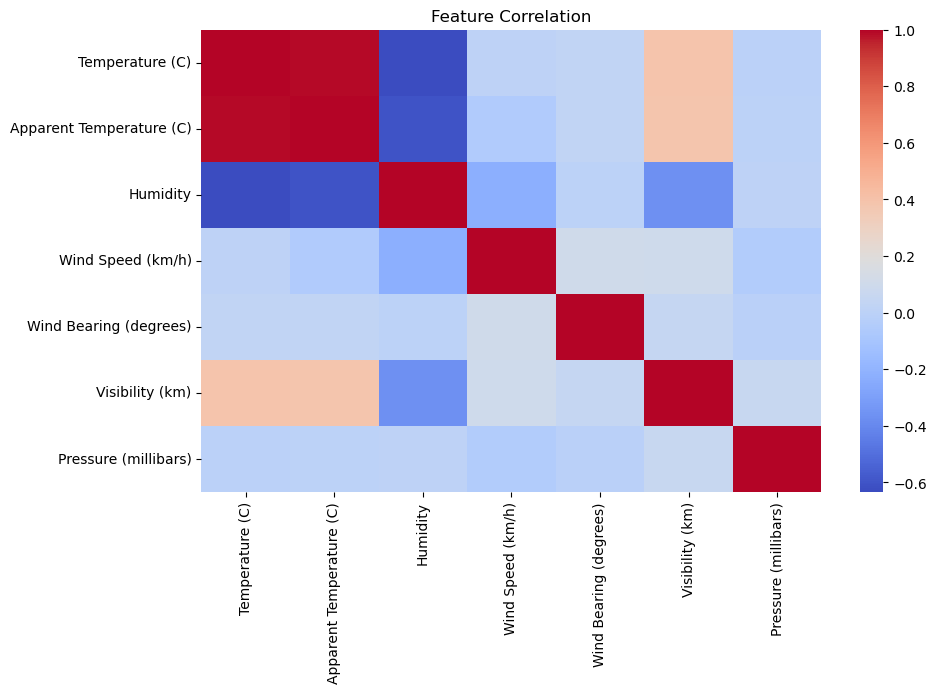

In [5]:
# Distribution
sns.histplot(df['Temperature (C)'])
plt.show()

sns.histplot(df['Humidity'])
plt.show()

# Boxplot
top_classes = df['Summary'].value_counts().nlargest(5).index

plt.figure(figsize=(10,5))
sns.boxplot(x='Summary', y='Temperature (C)', data=df[df['Summary'].isin(top_classes)])
plt.xticks(rotation=30)
plt.title("Temperature vs Top Weather Categories")
plt.show()

# Correlation
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


## Class Grouping

Similar weather conditions were grouped to reduce noise and improve learning.

In [6]:
df['Summary'] = df['Summary'].str.lower()

df['Summary'] = df['Summary'].apply(lambda x:
    'cloudy' if 'cloudy' in x else
    'rain' if 'rain' in x or 'drizzle' in x else
    'windy' if 'wind' in x or 'breezy' in x else
    'foggy' if 'fog' in x else
    'clear' if 'clear' in x else
    'other'
)

## Handling Class Imbalance

Rare classes (less than 200 samples) were removed to improve model stability.

In [7]:
class_counts = df['Summary'].value_counts()
df = df[df['Summary'].isin(class_counts[class_counts >= 200].index)]

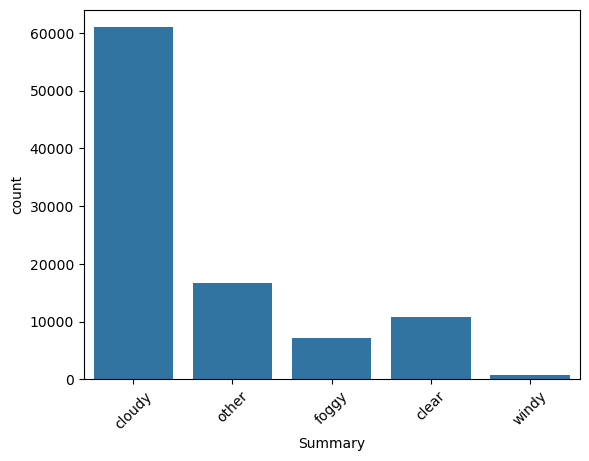

In [8]:
sns.countplot(x='Summary', data=df)
plt.xticks(rotation=45)
plt.show()

The dataset shows class imbalance with dominant categories.

## Encoding

Categorical variables were converted into numerical format.

In [9]:
df = pd.get_dummies(df, columns=['Precip Type'], drop_first=True)

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Summary'] = le.fit_transform(df['Summary'])

## Train-Test Split

Data was split before modeling to avoid data leakage.

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop('Summary', axis=1)
y = df['Summary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Care was taken to avoid data leakage by performing train-test split before model training and ensuring no target information was used in preprocessing.

## Model Pipeline

The machine learning workflow follows a structured pipeline:

- Data preprocessing and cleaning
- Feature selection and encoding
- Train-test split using stratified sampling
- Model training using Random Forest
- Hyperparameter tuning using GridSearchCV
- Evaluation using macro F1 score

This structured pipeline ensures reproducibility and prevents data leakage.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    
    results[name] = [acc, f1]
    
    print(name)
    print("Accuracy:", acc)
    print("F1 Macro:", f1)
    print(classification_report(y_test, preds))

Logistic Regression
Accuracy: 0.7188538205980066
F1 Macro: 0.5218774056152728
              precision    recall  f1-score   support

           0       0.63      0.06      0.11      2175
           1       0.72      0.95      0.82     12197
           2       0.89      0.96      0.92      1429
           3       0.54      0.21      0.30      3328
           4       0.52      0.41      0.46       135

    accuracy                           0.72     19264
   macro avg       0.66      0.52      0.52     19264
weighted avg       0.69      0.72      0.65     19264

Decision Tree
Accuracy: 0.6832433554817275
F1 Macro: 0.6269209528965891
              precision    recall  f1-score   support

           0       0.34      0.36      0.35      2175
           1       0.77      0.76      0.77     12197
           2       1.00      1.00      1.00      1429
           3       0.47      0.49      0.48      3328
           4       0.55      0.53      0.54       135

    accuracy                       

## 🔧 Hyperparameter Tuning (RandomForest)

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20],
    'model__min_samples_split': [2, 5]
}

pipe = Pipeline([
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ))
])

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=3,
    scoring='f1_macro',   
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [14]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred = best_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Final F1 Macro:", f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

Final Accuracy: 0.7567483388704319
Final F1 Macro: 0.7014294707523442

Classification Report:

              precision    recall  f1-score   support

           0       0.49      0.36      0.42      2175
           1       0.80      0.84      0.82     12197
           2       1.00      1.00      1.00      1429
           3       0.60      0.60      0.60      3328
           4       0.62      0.72      0.67       135

    accuracy                           0.76     19264
   macro avg       0.70      0.70      0.70     19264
weighted avg       0.75      0.76      0.75     19264



In [15]:
import joblib

joblib.dump(best_model, "model.pkl", compress=3)

print("model saved!")

model saved!


### Evaluation Metric Justification

The dataset is imbalanced, with some weather categories having significantly more samples than others.

Therefore, macro F1 score is used as the primary evaluation metric instead of accuracy, as it gives equal importance to all classes and provides a better measure of overall model performance.

### ROC AUC and ROC Curve

ROC AUC measures the model’s ability to distinguish between classes.

Since this is a multiclass problem, a one-vs-rest (OvR) strategy is used.  
The ROC curve shown below represents the performance for one class against all others.

The model achieves a high ROC AUC score, indicating strong classification performance.

In [16]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])

# Get prediction probabilities
y_pred_prob = best_model.predict_proba(X_test)

# Compute ROC AUC
roc_score = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr')

print("ROC AUC Score:", roc_score)

ROC AUC Score: 0.914584408390907


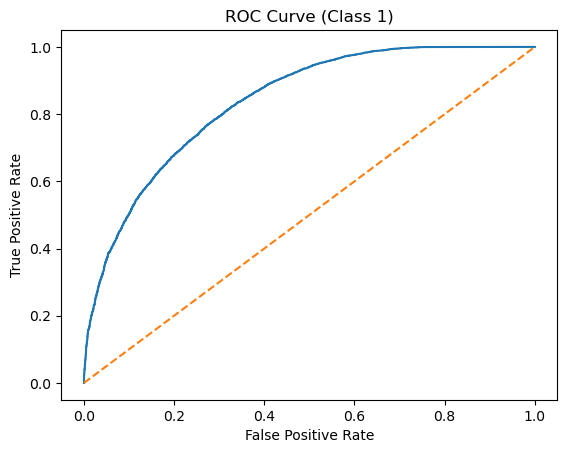

In [17]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Plot ROC for one class (example: class 1)
fpr, tpr, _ = roc_curve(y_test_bin[:,1], y_pred_prob[:,1])

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Class 1)")
plt.show()

## Error Analysis

The model performs well on dominant classes but struggles with minority classes due to overlapping feature patterns and class imbalance.

In [18]:
errors = X_test.copy()
errors['Actual'] = y_test
errors['Predicted'] = y_pred

errors[errors['Actual'] != errors['Predicted']].head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),Precip Type_snow,Actual,Predicted
72930,1.061111,-2.305556,0.85,11.1573,138,8.0017,1016.16,False,1,3
3573,-0.533333,-0.533333,0.92,3.5903,37,7.9051,1032.84,True,1,0
95170,14.688889,14.688889,0.83,8.6618,342,4.9588,1021.37,False,3,1
39475,13.800000,13.800000,0.93,9.6600,7,11.2700,1001.81,False,1,3
2040,-3.355556,-7.538889,0.88,10.8353,129,5.9731,1036.82,True,0,3


## Ablation Study

Feature engineering was evaluated using an ablation study.  
It resulted in a slight decrease in both accuracy and macro F1 score.

Therefore, feature engineering was not included in the final model.

## Conclusion

XGBoost achieved the best performance with balanced results across classes.

Proper preprocessing and class handling were key to model success, while feature engineering did not improve performance.

This project demonstrates the importance of evaluation metrics like macro F1 score in imbalanced classification problems.